# ETA

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

In [16]:
df = pd.read_csv('../data/processed/scheme_performance_clean.csv')

In [22]:
df2 = pd.read_csv('../data/processed/nav_history_clean.csv')

In [26]:
merged_df = pd.merge(df,df2,on='amfi_code')

In [27]:
merged_df.head(5)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,expense_ratio_flag,date,nav
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.7,14288,1.54,4,Moderate,False,2022-01-03,54.3856
1,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.7,14288,1.54,4,Moderate,False,2022-01-04,54.3474
2,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.7,14288,1.54,4,Moderate,False,2022-01-05,54.6869
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.7,14288,1.54,4,Moderate,False,2022-01-06,55.4550
4,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.7,14288,1.54,4,Moderate,False,2022-01-07,55.3692


In [52]:
scheme_name_list = merged_df['scheme_name'].unique().tolist()
scheme_name_list

['SBI Bluechip Fund - Regular Plan - Growth',
 'SBI Bluechip Fund - Direct Plan - Growth',
 'SBI Small Cap Fund - Regular Plan - Growth',
 'SBI Small Cap Fund - Direct Plan - Growth',
 'SBI Magnum Gilt Fund - Regular Plan - Growth',
 'HDFC Top 100 Fund - Regular Plan - Growth',
 'HDFC Top 100 Fund - Direct Plan - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Direct - Growth',
 'HDFC Short Term Debt Fund - Regular - Growth',
 'ICICI Pru Bluechip Fund - Regular - Growth',
 'ICICI Pru Bluechip Fund - Direct - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'ICICI Pru Value Discovery Fund - Regular - Growth',
 'ICICI Pru Liquid Fund - Regular - Growth',
 'Nippon India Large Cap Fund - Regular - Growth',
 'Nippon India Large Cap Fund - Direct - Growth',
 'Nippon India Small Cap Fund - Regular - Growth',
 'Nippon India ETF Nifty 50 BeES',
 'Nippon India Gilt Securities Fund - Regular - Growth',
 'Kotak Bluechip Fund - Regular - Gro

In [77]:
def plot_graph(x,fig,rows,cols,):
    masked_df =merged_df[ merged_df['scheme_name'] == f'{x}']
    trace = go.Scatter(
        x = masked_df['date'],
        y = masked_df['nav'],
        mode='lines',
        name=x
    )
    fig.add_trace(trace,row=rows,col=cols)

    fig.add_vrect(
        x0 = '2023-04-01',x1 ='2023-12-31',
        fillcolor = 'rgba(0,250,0,0.1)',
        layer='below',line_width=0,
        row = rows , col = cols 
    )

    fig.add_vrect(
        x0 = '2024-04-01',x1 ='2024-12-31',
        fillcolor = 'rgba(250,0,0,0.12)',
        layer='below',line_width=0,
        row = rows , col = cols 
    )

In [78]:
cols =4
rows = (len(scheme_name_list)+cols-1)//cols
print(rows)

fig = make_subplots(
    rows=rows,
    cols = cols,
    subplot_titles = scheme_name_list
)

for i,name in enumerate(scheme_name_list):
    current_row = (i//cols)+1
    current_cols = (i%cols) +1
    plot_graph(name,fig,current_row,current_cols)

fig.update_layout(
    height = rows *250,
    width = 12000,
    # showlegend = False,
    title = 'All schemes analysis',
    # tle_x = 0.5
)

fig.show()
# for name in scheme_name_list[:20]:
#     plot_graph(name)

10


In [79]:
df = pd.read_csv('../data/raw/03_aum_by_fund_house.csv')

In [83]:
df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
df.groupby('fund_house')

0     False
1     False
2     False
3     False
4     False
      ...  
85    False
86    False
87    False
88    False
89    False
Name: fund_house, Length: 90, dtype: bool

In [95]:
data ={
    'a':['q1','q2','q3','q1','q2','q3'],
    'b':['l','m','h','l','m','h'],
    'c':[5000,1200,300,5200,1500,450]
}
df2 = pd.DataFrame(data)

date                   2025-12-31
fund_house        UTI Mutual Fund
aum_lakh_crore               12.5
aum_crore                 1250000
num_schemes                   216
dtype: object

In [101]:
df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


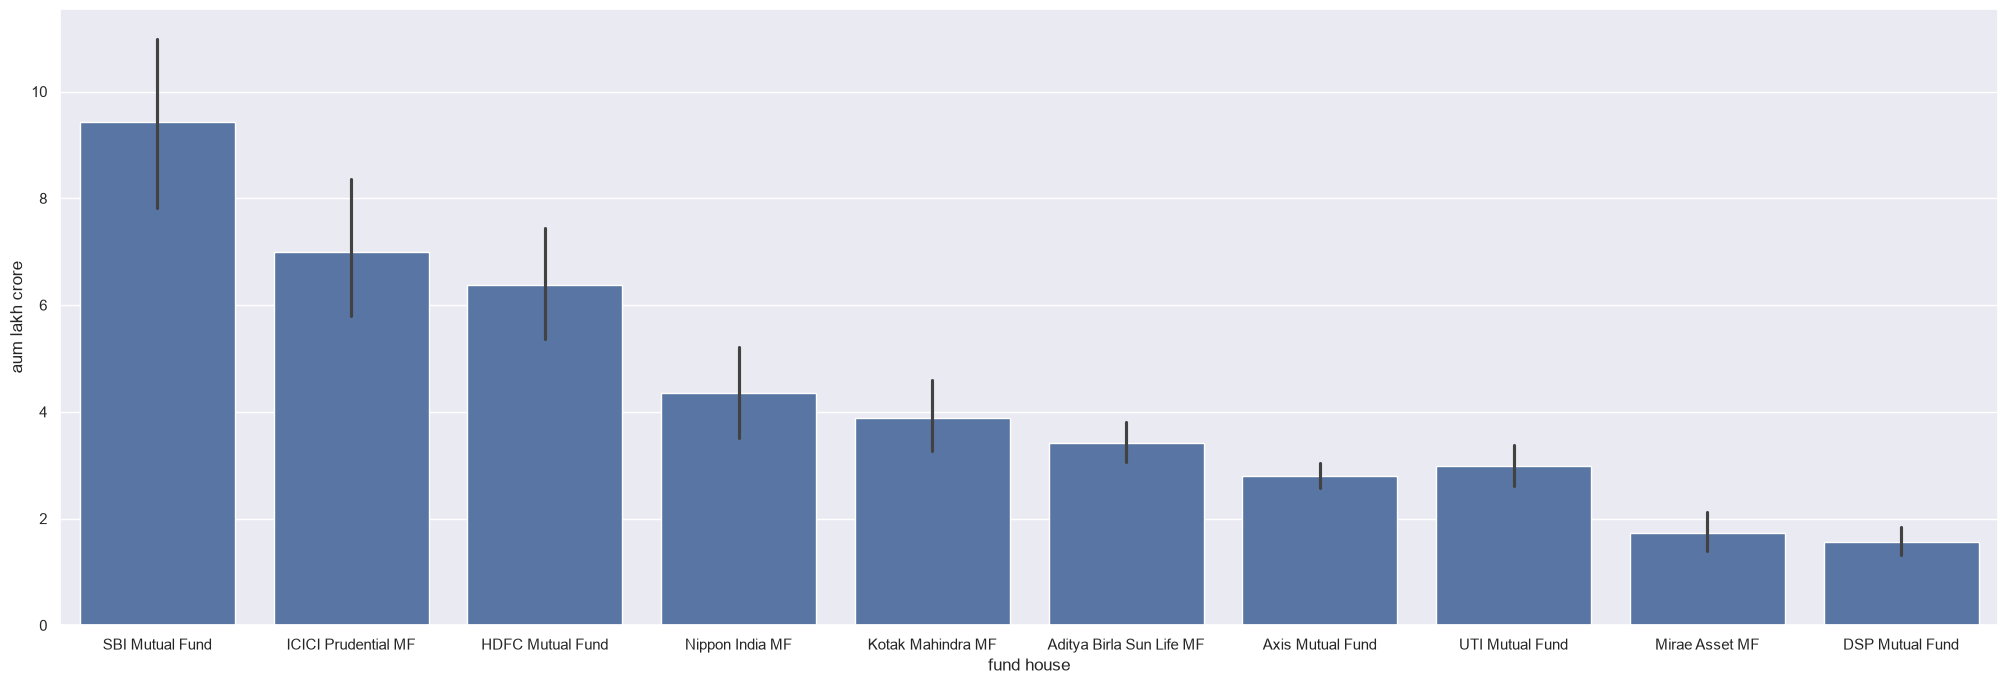

In [111]:
sns.set_theme()
plt.figure(figsize=(25,8))
sns.barplot(
    data=df,
    x='fund_house',
    y='aum_lakh_crore',
    # hue = 'c'
)

# plt.title('transaction volatility by account risk tier')
plt.xlabel('fund house')
plt.ylabel('aum lakh crore')

plt.show()

In [112]:
df = pd.read_csv('../data/raw/04_monthly_sip_inflows.csv')

In [113]:
df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [123]:
# highlight_colour = '#FF3333'
# base_colour = '#636EFA'
# df['bar_colour'] = df.apply(lambda row : highlight_colour if row == df['sip_inflow_crore'].max() else base_colour)

In [118]:
fig =px.bar(
    df,
    x = 'month',
    y = 'sip_inflow_crore',
    barmode = 'group'

)
fig.show()

In [126]:
df = pd.read_csv('../data/raw/05_category_inflows.csv')

In [127]:
df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [130]:
matrix = df.pivot(index = 'month',columns='category',values='net_inflow_crore')

In [131]:
matrix

category,ELSS,Flexi Cap,Gilt,Hybrid,Large & Mid Cap,Large Cap,Liquid,Mid Cap,Sectoral/Thematic,Short Duration,Small Cap,Value/Contra
month,,,,,,,,,,,,
2024-04,466.0,4947.0,784.0,2955.0,4214.0,2413.0,37537.0,3897.0,8052.0,4400.0,3533.0,1328.0
2024-05,553.0,5529.0,836.0,3487.0,4368.0,2076.0,41872.0,5300.0,8354.0,4833.0,4092.0,1361.0
2024-06,472.0,4478.0,864.0,3163.0,4610.0,2519.0,40486.0,5047.0,10030.0,4321.0,3535.0,1386.0
2024-07,471.0,4869.0,959.0,3291.0,5023.0,2574.0,34643.0,4548.0,9896.0,4170.0,3582.0,1582.0
2024-08,499.0,5562.0,952.0,3684.0,5411.0,1940.0,41952.0,3899.0,8360.0,4658.0,3376.0,1308.0
2024-09,537.0,5397.0,925.0,3015.0,4528.0,1879.0,35308.0,4960.0,8518.0,5327.0,4137.0,1334.0
2024-10,537.0,6004.0,898.0,3314.0,4581.0,2255.0,39091.0,4106.0,7680.0,4675.0,4444.0,1595.0
2024-11,571.0,6111.0,704.0,3264.0,5556.0,1870.0,40506.0,4336.0,7397.0,5316.0,3256.0,1436.0
2024-12,521.0,4654.0,831.0,3538.0,4878.0,1923.0,34933.0,5023.0,9820.0,4159.0,4249.0,1414.0


Text(0.5, 1.0, 'category inflow')

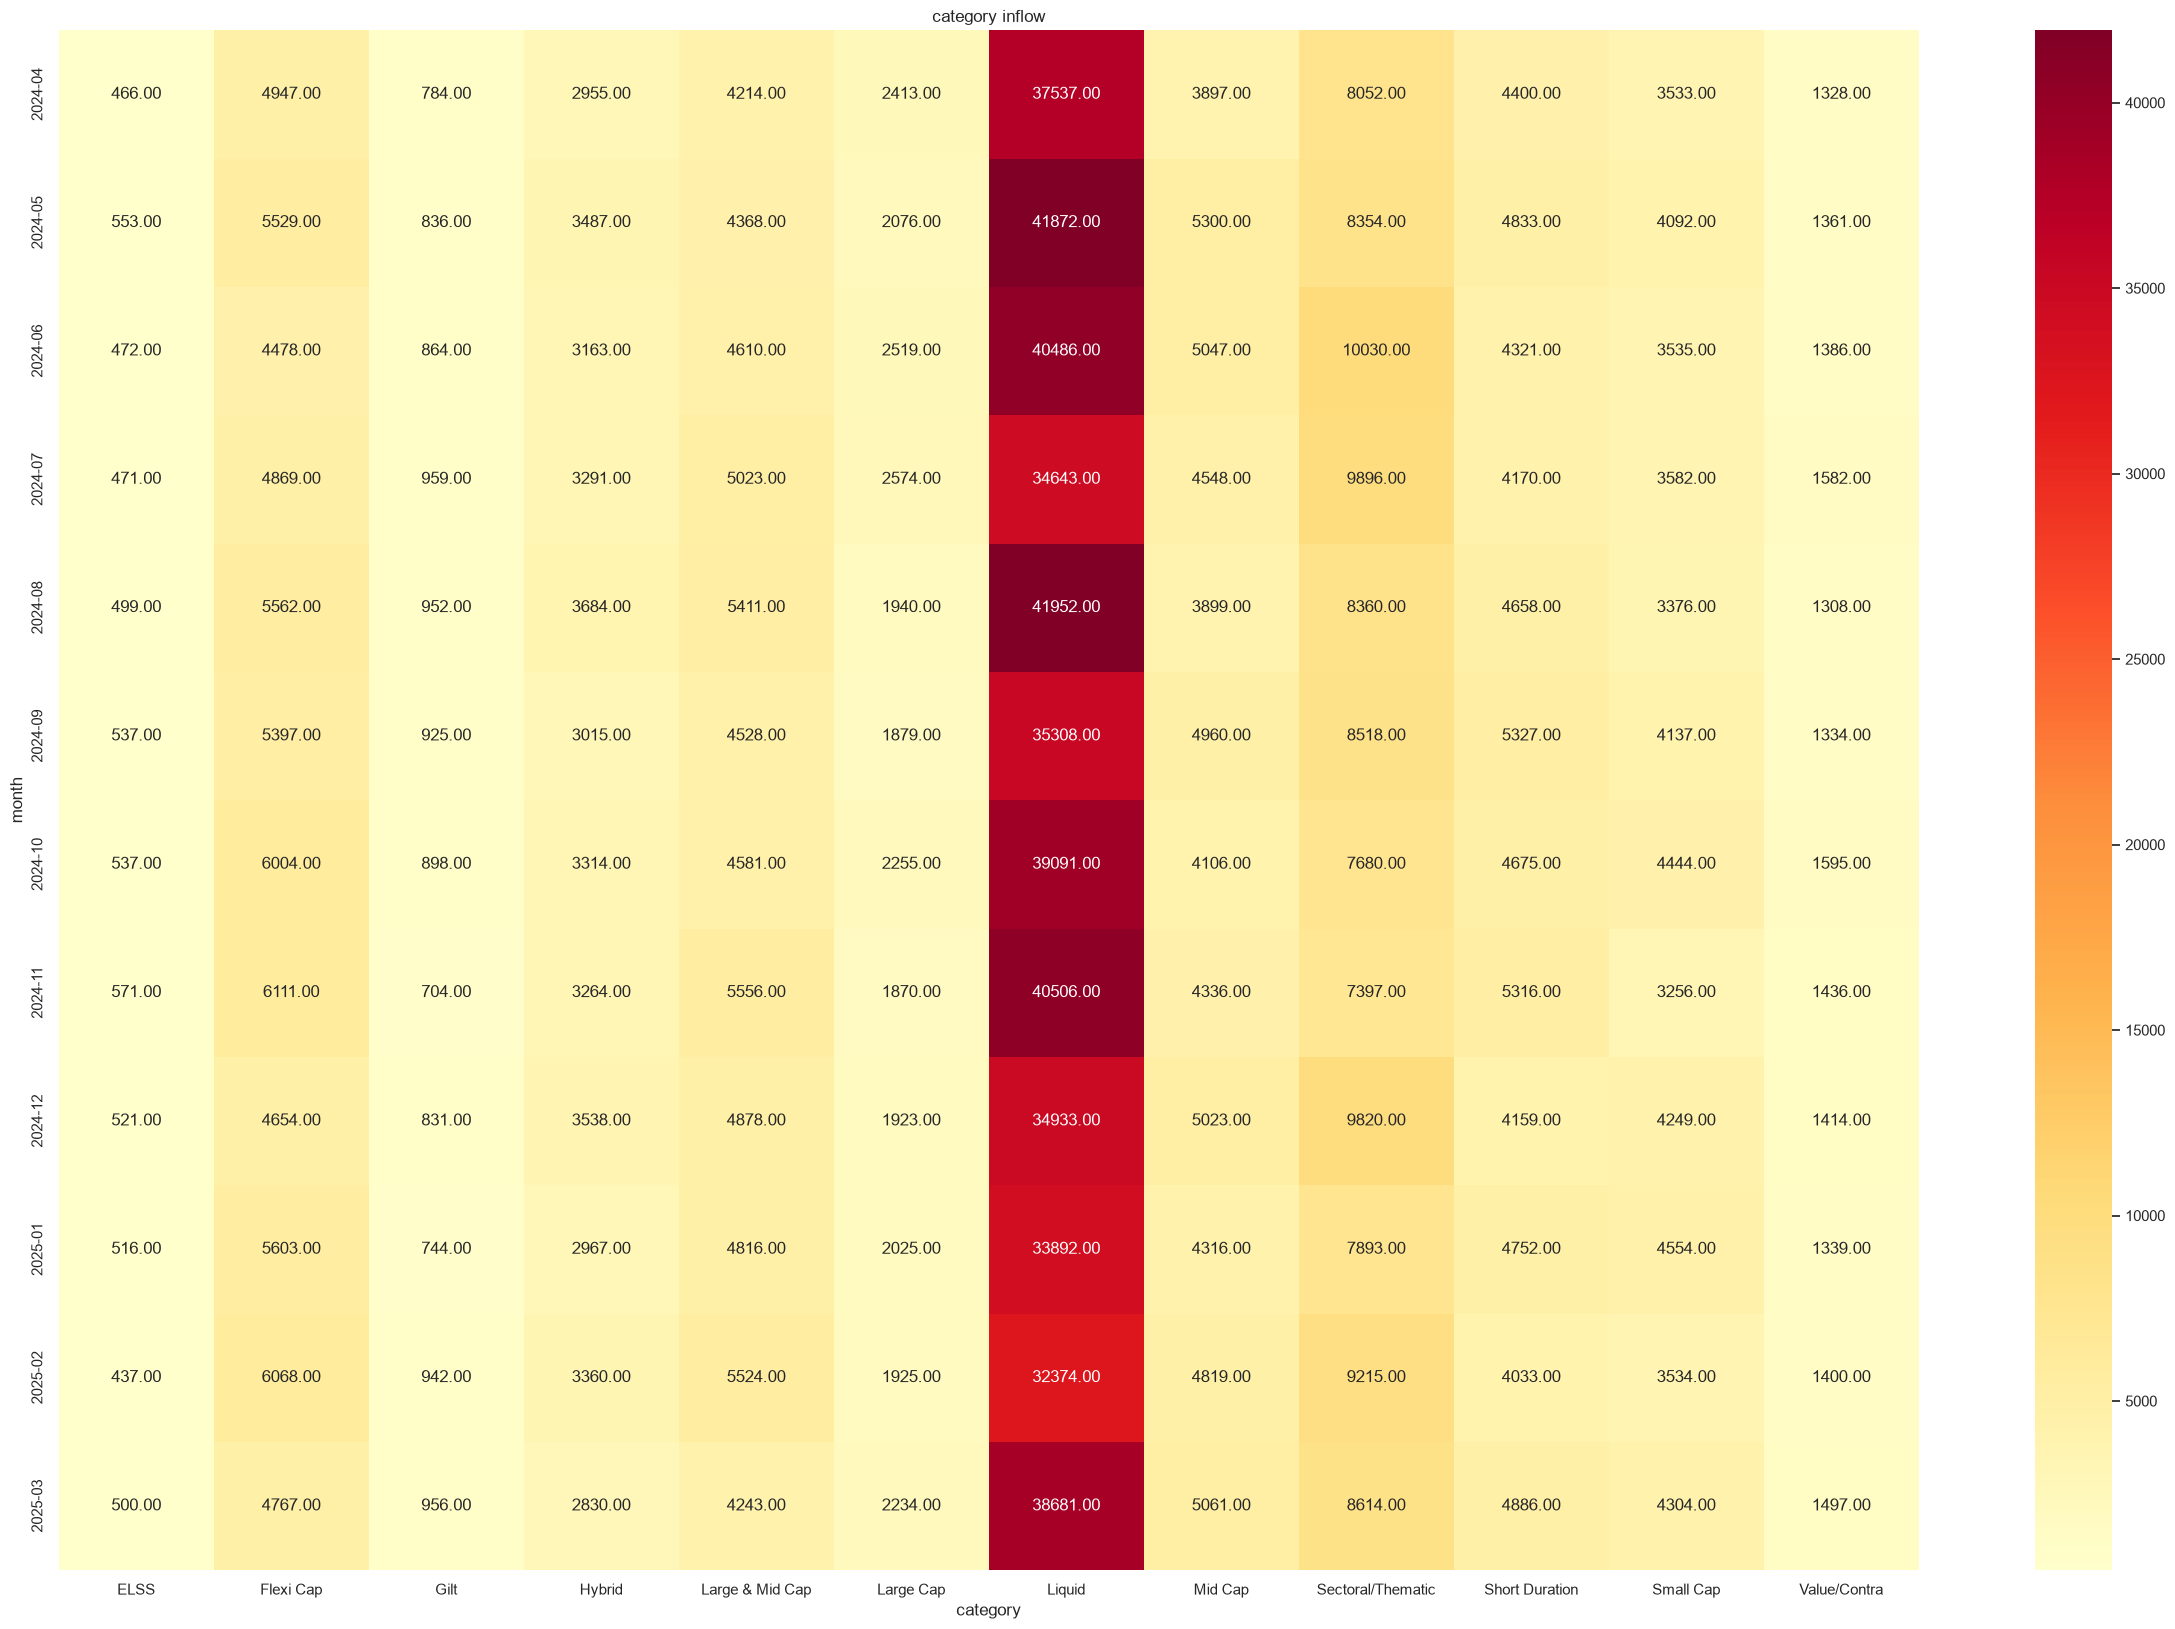

In [146]:
plt.figure(figsize=(30,20))
sns.heatmap(
    matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'YlOrRd',
    linecolor = 'white'
)

plt.title('category inflow')

In [147]:
df = pd.read_csv('../data/raw/08_investor_transactions.csv')

In [148]:
df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [164]:
sizes = df.groupby('age_group')['amount_inr'].sum()

In [156]:
labels = ['26-35','36-45','18-25','46-55','56+']
explode = (0,0,0.1,0.2)

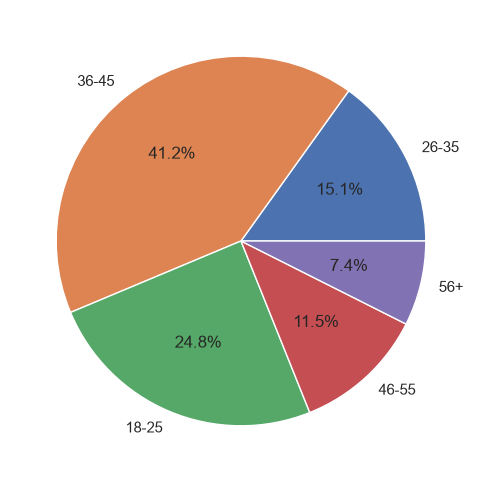

In [165]:
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    # explode = explode,
    labels = labels,
    autopct = '%1.1f%%'
)

# plt.tilte('age wise distribution')
plt.show()